# Comprehensive Workload Clustering Analysis

This notebook performs workload clustering using multiple approaches:
1. **Vector-based features**: Extracted SQL structural features (joins, aggregates, predicates, etc.)
2. **Word embeddings**: Multiple embedding types including:
   - FastText (subword-aware embeddings)
   - Word2Vec (context-based word embeddings)
   - TF-IDF (term frequency-inverse document frequency)
   - Sentence Transformers (BERT-based contextual embeddings)

The pipeline includes dimensionality reduction (UMAP & PCA), clustering (HDBSCAN), evaluation metrics, and visualization.

## 1. Import Required Libraries

### Installation Requirements

Run this cell if you need to install required packages:

```bash
pip install sqlglot umap-learn hdbscan pandas numpy matplotlib seaborn scikit-learn scipy gensim sentence-transformers
```

In [37]:
import os
import shutil
import sqlglot
import umap
import hdbscan
import pandas as pd
import numpy as np
import logging
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from sklearn.feature_extraction.text import TfidfVectorizer
import glob

# Embedding models
from gensim.models import FastText, Word2Vec
from sentence_transformers import SentenceTransformer

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
warnings.filterwarnings('ignore')

## 2. Feature Extraction Functions

These functions extract comprehensive SQL features including:
- Query structure (SELECT, JOIN, WHERE, GROUP BY, ORDER BY)
- Predicate types (AND, OR, LIKE, IN, BETWEEN)
- Complexity indicators (CASE, CAST, subqueries, CTEs)
- Join types (INNER, LEFT, RIGHT, FULL, CROSS)

In [38]:
def extract_sql_features(sql_query):
    """Extract comprehensive structural features from a SQL query."""
    features = {}
    try:
        statements = [s for s in sql_query.split(';') if s.strip()]
        counts = {
            'selects': 0, 'joins': 0, 'wheres': 0, 'groups': 0, 'orders': 0, 
            'limits': 0, 'subqueries': 0, 'aggregates': 0, 'ctes': 0, 
            'distinct_tables': set(), 
            'pred_and': 0, 'pred_or': 0, 'pred_like': 0, 'pred_in': 0, 
            'pred_between': 0, 'pred_exists': 0, 'pred_comparison': 0,
            'complexity_case': 0, 'complexity_cast': 0, 'complexity_alias': 0, 'complexity_window': 0,
            'join_inner': 0, 'join_left': 0, 'join_right': 0, 'join_full': 0, 'join_cross': 0
        }
        
        for stmt in statements:
            try:
                parsed = sqlglot.parse_one(stmt, read='postgres')
                counts['selects'] += len(list(parsed.find_all(sqlglot.exp.Select)))
                joins = list(parsed.find_all(sqlglot.exp.Join))
                counts['joins'] += len(joins)
                counts['wheres'] += len(list(parsed.find_all(sqlglot.exp.Where)))
                counts['groups'] += len(list(parsed.find_all(sqlglot.exp.Group)))
                counts['orders'] += 1 if list(parsed.find_all(sqlglot.exp.Order)) else 0
                counts['limits'] += 1 if list(parsed.find_all(sqlglot.exp.Limit)) else 0
                counts['subqueries'] += len(list(parsed.find_all(sqlglot.exp.Subquery)))
                counts['ctes'] += len(list(parsed.find_all(sqlglot.exp.CTE)))
                
                # Count aggregate functions
                for agg in (sqlglot.exp.Sum, sqlglot.exp.Avg, sqlglot.exp.Count, sqlglot.exp.Max, sqlglot.exp.Min):
                    counts['aggregates'] += len(list(parsed.find_all(agg)))
                
                counts['complexity_window'] += len(list(parsed.find_all(sqlglot.exp.Window)))
                
                # Count distinct tables
                for table in parsed.find_all(sqlglot.exp.Table):
                    counts['distinct_tables'].add(table.name.lower())
                
                # Count predicates
                counts['pred_and'] += len(list(parsed.find_all(sqlglot.exp.And)))
                counts['pred_or'] += len(list(parsed.find_all(sqlglot.exp.Or)))
                counts['pred_like'] += len(list(parsed.find_all(sqlglot.exp.Like)))
                counts['pred_in'] += len(list(parsed.find_all(sqlglot.exp.In)))
                counts['pred_between'] += len(list(parsed.find_all(sqlglot.exp.Between)))
                counts['pred_exists'] += len(list(parsed.find_all(sqlglot.exp.Exists)))
                
                for comp in (sqlglot.exp.GT, sqlglot.exp.LT, sqlglot.exp.GTE, sqlglot.exp.LTE, sqlglot.exp.NEQ):
                    counts['pred_comparison'] += len(list(parsed.find_all(comp)))
                
                # Count complexity indicators
                counts['complexity_case'] += len(list(parsed.find_all(sqlglot.exp.Case)))
                counts['complexity_cast'] += len(list(parsed.find_all(sqlglot.exp.Cast))) + len(list(parsed.find_all(sqlglot.exp.TryCast)))
                counts['complexity_alias'] += len(list(parsed.find_all(sqlglot.exp.Alias)))
                
                # Count join types
                for j in joins:
                    kind = j.kind
                    if kind == 'CROSS': counts['join_cross'] += 1
                    elif kind == 'FULL': counts['join_full'] += 1
                    elif kind == 'LEFT': counts['join_left'] += 1
                    elif kind == 'RIGHT': counts['join_right'] += 1
                    else: counts['join_inner'] += 1
            except: 
                continue
        
        features = {k: (len(v) if isinstance(v, set) else v) for k, v in counts.items()}
    except: 
        return None
    
    return features

In [39]:
def get_vector_workload_features(file_path):
    """Extract workload-level statistical features from all queries in a file."""
    with open(file_path, 'r') as f:
        queries = f.readlines()
    
    all_feats = [extract_sql_features(q) for q in queries if q.strip()]
    all_feats = [f for f in all_feats if f]
    
    if not all_feats: 
        return None
    
    df = pd.DataFrame(all_feats)
    stats = {}
    
    # Compute mean, median, std, and percentiles for each feature
    for col in df.columns:
        stats[f"{col}_mean"] = df[col].mean()
        stats[f"{col}_median"] = df[col].median()
        stats[f"{col}_std"] = df[col].std() if len(df) > 1 else 0
        stats[f"{col}_p25"] = np.percentile(df[col], 25)
        stats[f"{col}_p75"] = np.percentile(df[col], 75)
    
    return stats

## 3. Multi-Model Embedding Functions

These functions support multiple embedding types:
- **FastText**: Subword-aware embeddings that handle rare tokens
- **Word2Vec**: Traditional context-based word embeddings
- **TF-IDF**: Statistical token importance weighting
- **Sentence Transformers**: Transformer-based contextual embeddings (e.g., BERT, MPNet)

In [40]:
def tokenize_query(query):
    """Tokenize a SQL query using sqlglot parser."""
    try:
        parsed = sqlglot.parse_one(query, read='postgres')
        return [str(token).lower() for token in parsed.flatten() if token]
    except:
        return query.lower().replace(',', ' , ').replace('(', ' ( ').replace(')', ' ) ').split()

In [41]:
def get_word_workload_embedding(file_path, model, model_type='fasttext'):
    """Generate workload-level embedding from various embedding models.
    
    Args:
        file_path: Path to workload file
        model: The embedding model (FastText, Word2Vec, TF-IDF vectorizer, or SentenceTransformer)
        model_type: One of 'fasttext', 'word2vec', 'tfidf', 'sentence_transformer'
    
    Returns:
        Workload-level embedding vector
    """
    try:
        with open(file_path, 'r') as f:
            queries = f.readlines()
        queries = [q.strip() for q in queries if q.strip()]
        
        if not queries:
            return None
        
        if model_type in ['fasttext', 'word2vec']:
            # Word-level embeddings (FastText or Word2Vec)
            q_embs = []
            for q in queries:
                tokens = tokenize_query(q)
                vectors = [model.wv[t] for t in tokens if t in model.wv]
                if vectors: 
                    q_embs.append(np.mean(vectors, axis=0))
            
            if not q_embs: 
                return None
            
            q_embs = np.array(q_embs)
            
            # Concatenate mean, std, and percentiles
            return np.concatenate([
                np.mean(q_embs, axis=0), 
                np.std(q_embs, axis=0),
                np.percentile(q_embs, 25, axis=0),
                np.percentile(q_embs, 75, axis=0)
            ])
            
        elif model_type == 'tfidf':
            # TF-IDF embeddings
            # Model is already fitted, just transform
            tfidf_matrix = model.transform(queries)
            # Aggregate across queries using mean, std, and percentiles
            if tfidf_matrix.shape[0] == 0:
                return None
            dense = tfidf_matrix.toarray()
            return np.concatenate([
                np.mean(dense, axis=0),
                np.std(dense, axis=0),
                np.percentile(dense, 25, axis=0),
                np.percentile(dense, 75, axis=0)
            ])
            
        elif model_type == 'sentence_transformer':
            # Sentence Transformer embeddings
            embeddings = model.encode(queries, show_progress_bar=False)
            if len(embeddings) == 0:
                return None
            # Aggregate across queries
            return np.concatenate([
                np.mean(embeddings, axis=0),
                np.std(embeddings, axis=0),
                np.percentile(embeddings, 25, axis=0),
                np.percentile(embeddings, 75, axis=0)
            ])
            
        else:
            raise ValueError(f"Unknown model_type: {model_type}")
            
    except Exception as e:
        logging.warning(f"Error processing {file_path} with {model_type}: {e}")
        return None

## 4. Clustering Evaluation Metrics

Functions to compute:
- Inertia (within-cluster sum of squares)
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index

In [42]:
def calculate_inertia(embedding, labels):
    """Calculate within-cluster sum of squares."""
    inertia = 0
    unique_labels = set(labels)
    
    for label in unique_labels:
        if label == -1: 
            continue
        points = embedding[labels == label]
        centroid = np.mean(points, axis=0)
        inertia += np.sum(np.sum((points - centroid) ** 2, axis=1))
    
    return inertia

In [43]:
def evaluate_clustering(embedding, labels):
    """Compute comprehensive clustering evaluation metrics."""
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
    inertia = calculate_inertia(embedding, labels)
    
    if n_clusters < 2:
        return {"Sil": -1.0, "DB": 10.0, "CH": 0.0, "Inertia": inertia, "Noise": list(labels).count(-1)}
    
    # Exclude noise points for metric calculation
    mask = labels != -1
    X = embedding[mask]
    L = labels[mask]
    
    if len(set(L)) < 2:
        return {"Sil": -1.0, "DB": 10.0, "CH": 0.0, "Inertia": inertia, "Noise": list(labels).count(-1)}

    return {
        "Sil": silhouette_score(X, L),
        "DB": davies_bouldin_score(X, L),
        "CH": calinski_harabasz_score(X, L),
        "Inertia": inertia,
        "Noise": list(labels).count(-1)
    }

## 5. Clustering Engine

Performs grid search over UMAP and HDBSCAN hyperparameters to find the best clustering configuration.

In [44]:
def run_clustering(X_scaled, n_samples):
    """Run clustering with improved hyperparameter grid search.
    
    Features:
    - Adaptive n_neighbors based on dataset size
    - Expanded min_dist range for better layout control
    - Multiple distance metrics (euclidean, cosine)
    - Improved composite scoring with normalized metrics
    - More granular min_cluster_size options for finer clusters
    - cluster_selection_method options for different granularity
    """
    best_score = -float('inf')
    best_res = None
    best_params = None
    
    # Adaptive n_neighbors based on dataset size
    max_neighbors = min(n_samples - 1, 50)
    if n_samples <= 10:
        neighbor_options = [3, 5]
    elif n_samples <= 20:
        neighbor_options = [5, 10]
    elif n_samples <= 50:
        neighbor_options = [5, 10, 15, 20]
    else:
        neighbor_options = [5, 10, 15, 20, 30]
    
    # Filter out invalid neighbor values
    neighbor_options = [n for n in neighbor_options if n < n_samples]
    
    # Expanded min_dist range - smaller values preserve local structure better
    min_dist_options = [0.0, 0.05, 0.1, 0.2, 0.3]
    
    # Try multiple distance metrics
    metric_options = ['euclidean', 'cosine']
    
    # More granular min_cluster_size for finer clustering
    # Lower values will find smaller, more specific clusters
    if n_samples <= 10:
        cluster_size_options = [2]
    elif n_samples <= 20:
        cluster_size_options = [2, 3]
    else:
        cluster_size_options = [2, 3, 4, 5]  # Added more options
    
    # Try different cluster selection methods
    # 'eom' (Excess of Mass) - more clusters, better for nested structure
    # 'leaf' - even more granular, picks leaf nodes
    selection_methods = ['eom', 'leaf']
    
    # Track max CH score for normalization
    max_ch = 0.0
    all_results = []
    
    total_configs = len(neighbor_options) * len(min_dist_options) * len(metric_options) * len(cluster_size_options) * len(selection_methods)
    print(f"      Grid search: {len(neighbor_options)} neighbors × {len(min_dist_options)} min_dist × {len(metric_options)} metrics × {len(cluster_size_options)} HDBSCAN sizes × {len(selection_methods)} selection methods = {total_configs} configurations")
    
    # Grid search over UMAP parameters
    for metric in metric_options:
        for nn in neighbor_options:
            for md in min_dist_options:
                try:
                    reducer = umap.UMAP(
                        n_components=2, 
                        n_neighbors=nn, 
                        min_dist=md, 
                        metric=metric,
                        random_state=42
                    )
                    embedding = reducer.fit_transform(X_scaled)
                    
                    # Grid search over HDBSCAN parameters
                    for mcs in cluster_size_options:
                        if mcs > n_samples: 
                            continue
                        
                        for selection_method in selection_methods:
                            try:
                                clusterer = hdbscan.HDBSCAN(
                                    min_cluster_size=mcs, 
                                    min_samples=1,  # Keep at 1 for more granularity
                                    cluster_selection_method=selection_method
                                )
                                labels = clusterer.fit_predict(embedding)
                                metrics = evaluate_clustering(embedding, labels)
                                
                                # Count actual clusters
                                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                                
                                # Track max CH for normalization
                                if metrics['CH'] > max_ch:
                                    max_ch = metrics['CH']
                                
                                all_results.append({
                                    'embedding': embedding,
                                    'labels': labels,
                                    'metrics': metrics,
                                    'n_clusters': n_clusters,
                                    'params': {'nn': nn, 'md': md, 'metric': metric, 'mcs': mcs, 'selection': selection_method}
                                })
                            except Exception as e:
                                continue
                except Exception as e:
                    # Skip configurations that fail
                    continue
    
    # Second pass: compute normalized scores
    # Bonus for having more clusters (but not too many)
    optimal_clusters = max(3, int(np.sqrt(n_samples)))  # Rule of thumb
    
    for result in all_results:
        metrics = result['metrics']
        n_clusters = result['n_clusters']
        
        # Normalize metrics to [0, 1] scale
        sil_norm = (metrics['Sil'] + 1) / 2  # [-1,1] → [0,1]
        db_norm = 1 / (1 + metrics['DB'])     # Lower DB is better, normalize to [0,1]
        ch_norm = metrics['CH'] / max_ch if max_ch > 0 else 0  # Normalize by max
        noise_penalty = metrics['Noise'] / n_samples
        
        # Add bonus for having reasonable number of clusters
        # Prefer solutions with 3+ clusters but penalize too many
        if n_clusters >= 3 and n_clusters <= optimal_clusters:
            cluster_bonus = 0.2  # Bonus for multiple clusters
        elif n_clusters > optimal_clusters:
            cluster_bonus = 0.1 - (0.01 * (n_clusters - optimal_clusters))  # Penalty for too many
        else:
            cluster_bonus = 0  # No bonus for 1-2 clusters
        
        # Composite score: balance all metrics equally
        score = sil_norm + db_norm + ch_norm - noise_penalty + cluster_bonus
        
        if score > best_score:
            best_score = score
            best_res = (result['embedding'], result['labels'], result['metrics'])
            best_params = result['params']
    
    # Log best parameters
    if best_params and best_res:
        n_clusters_found = len(set(best_res[1])) - (1 if -1 in best_res[1] else 0)
        print(f"      Best params: n_neighbors={best_params['nn']}, min_dist={best_params['md']}, metric={best_params['metric']}, min_cluster_size={best_params['mcs']}, selection={best_params['selection']}")
        print(f"      Found {n_clusters_found} clusters")
    
    return best_res


## 6. Configuration

Set up paths and parameters for the analysis.

In [45]:
# Configure paths
workload_dir = "/Users/nisith/Desktop/FYP/E2ETune-AI4DB/olap_workloads"
output_dir = "/Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering_output"

# Create output directory
if os.path.exists(output_dir): 
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

print(f"Workload directory: {workload_dir}")
print(f"Output directory: {output_dir}")

Workload directory: /Users/nisith/Desktop/FYP/E2ETune-AI4DB/olap_workloads
Output directory: /Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering_output


## 7. Load and Organize Workload Files

In [46]:
# Find all workload files
all_files = glob.glob(os.path.join(workload_dir, "*.wg"))
print(f"Found {len(all_files)} workload files")

# Group files by benchmark name (first part of filename)
benchmarks = {}
for f in all_files:
    b_name = os.path.basename(f).split('_')[0]
    if b_name not in benchmarks: 
        benchmarks[b_name] = []
    benchmarks[b_name].append(f)

print(f"Grouped into {len(benchmarks)} benchmark categories")
for b_name, files in benchmarks.items():
    print(f"  {b_name}: {len(files)} workloads")

Found 1275 workload files
Grouped into 4 benchmark categories
  tpcds: 233 workloads
  ssb: 526 workloads
  job: 244 workloads
  tpch: 272 workloads


## 8. Train All Embedding Models

Train multiple embedding models on all SQL tokens/queries from workloads:
- **FastText**: 100-dim subword embeddings
- **Word2Vec**: 100-dim word embeddings  
- **TF-IDF**: Statistical token importance (max 500 features)
- **Sentence Transformer**: Pre-trained 'all-MiniLM-L6-v2' model (384-dim)

In [47]:
print("=" * 60)
print("TRAINING EMBEDDING MODELS")
print("=" * 60)

# Collect all tokens and queries from all workloads
all_tokens = []
all_queries = []

for f in all_files:
    with open(f, 'r') as file:
        for q in file:
            q_stripped = q.strip()
            if q_stripped:
                all_queries.append(q_stripped)
                tokens = tokenize_query(q_stripped)
                if tokens: 
                    all_tokens.append(tokens)

print(f"\nCollected {len(all_queries)} queries for training")

# 1. Train FastText model
print("\n1. Training FastText model...")
ft_model = FastText(sentences=all_tokens, vector_size=100, window=5, min_count=1, workers=4, epochs=5)
print("   ✓ FastText model trained")

# 2. Train Word2Vec model
print("\n2. Training Word2Vec model...")
w2v_model = Word2Vec(sentences=all_tokens, vector_size=100, window=5, min_count=1, workers=4, epochs=5)
print("   ✓ Word2Vec model trained")

# 3. Train TF-IDF vectorizer
print("\n3. Training TF-IDF vectorizer...")
tfidf_vectorizer = TfidfVectorizer(max_features=500, tokenizer=tokenize_query, lowercase=True)
tfidf_vectorizer.fit(all_queries)
print(f"   ✓ TF-IDF vectorizer trained ({len(tfidf_vectorizer.get_feature_names_out())} features)")

# 4. Load pre-trained Sentence Transformer
print("\n4. Loading Sentence Transformer (all-MiniLM-L6-v2)...")
sent_model = SentenceTransformer('all-MiniLM-L6-v2')
print("   ✓ Sentence Transformer loaded")

print("\n" + "=" * 60)
print("ALL MODELS READY")
print("=" * 60)

# Store models in a dictionary for easy iteration
embedding_models = {
    'fasttext': (ft_model, 'fasttext'),
    'word2vec': (w2v_model, 'word2vec'),
    'tfidf': (tfidf_vectorizer, 'tfidf'),
    'sentence_transformer': (sent_model, 'sentence_transformer')
}

TRAINING EMBEDDING MODELS


INFO: collecting all words and their counts
INFO: PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO: PROGRESS: at sentence #10000, processed 65989 words, keeping 9671 word types
INFO: collected 14700 word types from a corpus of 118028 raw words and 17925 sentences
INFO: Creating a fresh vocabulary
INFO: FastText lifecycle event {'msg': 'effective_min_count=1 retains 14700 unique words (100.00% of original 14700, drops 0)', 'datetime': '2026-02-16T18:29:50.218386', 'gensim': '4.4.0', 'python': '3.11.10 (main, Aug  2 2025, 20:00:22) [Clang 14.0.0 (clang-1400.0.29.202)]', 'platform': 'macOS-12.5-arm64-arm-64bit', 'event': 'prepare_vocab'}
INFO: FastText lifecycle event {'msg': 'effective_min_count=1 leaves 118028 word corpus (100.00% of original 118028, drops 0)', 'datetime': '2026-02-16T18:29:50.219122', 'gensim': '4.4.0', 'python': '3.11.10 (main, Aug  2 2025, 20:00:22) [Clang 14.0.0 (clang-1400.0.29.202)]', 'platform': 'macOS-12.5-arm64-arm-64bit', 'event': 'prepar


Collected 17925 queries for training

1. Training FastText model...


INFO: estimated required memory for 14700 words, 2000000 buckets and 100 dimensions: 831772228 bytes
INFO: resetting layer weights
INFO: FastText lifecycle event {'update': False, 'trim_rule': 'None', 'datetime': '2026-02-16T18:29:53.625565', 'gensim': '4.4.0', 'python': '3.11.10 (main, Aug  2 2025, 20:00:22) [Clang 14.0.0 (clang-1400.0.29.202)]', 'platform': 'macOS-12.5-arm64-arm-64bit', 'event': 'build_vocab'}
INFO: FastText lifecycle event {'msg': 'training model with 4 workers on 14700 vocabulary and 100 features, using sg=0 hs=0 sample=0.001 negative=5 window=5 shrink_windows=True', 'datetime': '2026-02-16T18:29:53.628368', 'gensim': '4.4.0', 'python': '3.11.10 (main, Aug  2 2025, 20:00:22) [Clang 14.0.0 (clang-1400.0.29.202)]', 'platform': 'macOS-12.5-arm64-arm-64bit', 'event': 'train'}
INFO: EPOCH 0: training on 118028 raw words (103003 effective words) took 0.7s, 156834 effective words/s
INFO: EPOCH 1: training on 118028 raw words (103000 effective words) took 0.6s, 162632 effe

   ✓ FastText model trained

2. Training Word2Vec model...


...

   ✓ Word2Vec model trained

3. Training TF-IDF vectorizer...


INFO: Use pytorch device_name: cpu
INFO: Load pretrained SentenceTransformer: all-MiniLM-L6-v2


   ✓ TF-IDF vectorizer trained (500 features)

4. Loading Sentence Transformer (all-MiniLM-L6-v2)...


INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f20741

   ✓ Sentence Transformer loaded

ALL MODELS READY


## 9. Process Each Benchmark with All Embedding Models

For each benchmark and each embedding model:
1. Extract vector-based features and embeddings
2. Run clustering with UMAP and evaluate
3. Run PCA for comparison
4. Visualize results
5. Select representative workloads

In [48]:
summary_results = []
# Store clustering results for later representative selection
clustering_results_storage = {}

for b_name, files in benchmarks.items():
    # Skip benchmarks with too few workloads
    if len(files) < 5: 
        print(f"Skipping {b_name} (only {len(files)} workloads)")
        continue
    
    print(f"\n{'='*80}")
    print(f"Processing {b_name} ({len(files)} workloads)...")
    print(f"{'='*80}")
    
    # --- VECTOR-BASED FEATURES ---
    print("\n1. Extracting vector-based features...")
    vec_data = [get_vector_workload_features(f) for f in files]
    vec_data = [d for d in vec_data if d]
    X_vec = StandardScaler().fit_transform(pd.DataFrame(vec_data).fillna(0))
    print(f"   Vector features shape: {X_vec.shape}")
    
    # Run UMAP clustering
    print("   Running UMAP clustering...")
    emb_v_umap, lbl_v, met_v = run_clustering(X_vec, len(X_vec))
    print(f"   Vector UMAP metrics: Sil={met_v['Sil']:.3f}, DB={met_v['DB']:.3f}, CH={met_v['CH']:.1f}, Noise={met_v['Noise']}")
    
    # Run PCA
    print("   Running PCA...")
    pca_v = PCA(n_components=2, random_state=42)
    emb_v_pca = pca_v.fit_transform(X_vec)
    
    # Add vector metrics to results
    summary_results.append({
        "Benchmark": b_name, "Method": "Vector",
        "Silhouette": met_v['Sil'], "Davies-Bouldin": met_v['DB'], 
        "Calinski-Harabasz": met_v['CH'], "Inertia": met_v['Inertia'], 
        "Noise Points": met_v['Noise']
    })
    
    # --- PROCESS ALL EMBEDDING MODELS ---
    print("\n2. Processing all embedding models...")
    embedding_results = {}
    
    for emb_name, (model, model_type) in embedding_models.items():
        print(f"\n   {emb_name.upper()}:")
        
        # Extract embeddings
        emb_data = [get_word_workload_embedding(f, model, model_type) for f in files]
        emb_data = [d for d in emb_data if d is not None]
        
        if not emb_data or len(emb_data) < 5:
            print(f"      ⚠ Insufficient data for {emb_name}, skipping...")
            continue
            
        X_emb = StandardScaler().fit_transform(np.array(emb_data))
        print(f"      Features shape: {X_emb.shape}")
        
        # Run UMAP clustering
        print(f"      Running UMAP clustering...")
        emb_umap, lbl_emb, met_emb = run_clustering(X_emb, len(X_emb))
        print(f"      Metrics: Sil={met_emb['Sil']:.3f}, DB={met_emb['DB']:.3f}, CH={met_emb['CH']:.1f}, Noise={met_emb['Noise']}")
        
        # Run PCA
        pca_emb = PCA(n_components=2, random_state=42)
        emb_pca = pca_emb.fit_transform(X_emb)
        
        # Store results
        embedding_results[emb_name] = {
            'umap_emb': emb_umap,
            'pca_emb': emb_pca,
            'labels': lbl_emb,
            'metrics': met_emb
        }
        
        # Add to summary
        summary_results.append({
            "Benchmark": b_name, "Method": emb_name.replace('_', ' ').title(),
            "Silhouette": met_emb['Sil'], "Davies-Bouldin": met_emb['DB'], 
            "Calinski-Harabasz": met_emb['CH'], "Inertia": met_emb['Inertia'], 
            "Noise Points": met_emb['Noise']
        })
    
    # Store clustering results for later representative selection
    clustering_results_storage[b_name] = {
        'files': files,
        'embedding_results': embedding_results
    }
    
    # --- VISUALIZATION ---
    print("\n3. Creating comprehensive visualizations...")
    
    # Create a large figure with subplots for all methods
    n_methods = 1 + len(embedding_results)  # Vector + all embeddings
    n_cols = min(3, n_methods)
    n_rows = (n_methods * 2 + n_cols - 1) // n_cols  # *2 for UMAP and PCA
    
    fig = plt.figure(figsize=(6 * n_cols, 5 * n_rows))
    
    plot_idx = 1
    
    # Plot Vector method (UMAP)
    ax = fig.add_subplot(n_rows, n_cols, plot_idx)
    scatter = ax.scatter(emb_v_umap[:, 0], emb_v_umap[:, 1], c=lbl_v, cmap='Spectral', 
                        s=50, edgecolors='black', linewidth=0.5, alpha=0.7)
    ax.set_title(f"{b_name} - Vector (UMAP)\nSil={met_v['Sil']:.3f}", fontweight='bold')
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    plt.colorbar(scatter, ax=ax)
    plot_idx += 1
    
    # Plot Vector method (PCA)
    ax = fig.add_subplot(n_rows, n_cols, plot_idx)
    scatter = ax.scatter(emb_v_pca[:, 0], emb_v_pca[:, 1], c=lbl_v, cmap='Spectral', 
                        s=50, edgecolors='black', linewidth=0.5, alpha=0.7)
    ax.set_title(f"{b_name} - Vector (PCA)", fontweight='bold')
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    plt.colorbar(scatter, ax=ax)
    plot_idx += 1
    
    # Plot all embedding methods
    for emb_name, results in embedding_results.items():
        # UMAP
        ax = fig.add_subplot(n_rows, n_cols, plot_idx)
        scatter = ax.scatter(results['umap_emb'][:, 0], results['umap_emb'][:, 1], 
                            c=results['labels'], cmap='Spectral', 
                            s=50, edgecolors='black', linewidth=0.5, alpha=0.7)
        title = emb_name.replace('_', ' ').title()
        ax.set_title(f"{b_name} - {title} (UMAP)\nSil={results['metrics']['Sil']:.3f}", 
                    fontweight='bold')
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        plt.colorbar(scatter, ax=ax)
        plot_idx += 1
        
        # PCA
        ax = fig.add_subplot(n_rows, n_cols, plot_idx)
        scatter = ax.scatter(results['pca_emb'][:, 0], results['pca_emb'][:, 1], 
                            c=results['labels'], cmap='Spectral', 
                            s=50, edgecolors='black', linewidth=0.5, alpha=0.7)
        ax.set_title(f"{b_name} - {title} (PCA)", fontweight='bold')
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")
        plt.colorbar(scatter, ax=ax)
        plot_idx += 1
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{b_name}_all_methods_comparison.png"), dpi=150)
    plt.close()
    print(f"   ✓ Saved comprehensive visualization")

print("\n" + "="*80)
print("CLUSTERING COMPLETE - Results stored for representative selection")
print("="*80)



Processing tpcds (233 workloads)...

1. Extracting vector-based features...
   Vector features shape: (233, 130)
   Running UMAP clustering...
      Grid search: 5 neighbors × 5 min_dist × 2 metrics × 4 HDBSCAN sizes × 2 selection methods = 400 configurations
      Best params: n_neighbors=5, min_dist=0.05, metric=cosine, min_cluster_size=2, selection=leaf
      Found 65 clusters
   Vector UMAP metrics: Sil=0.615, DB=0.421, CH=7210.7, Noise=18
   Running PCA...

2. Processing all embedding models...

   FASTTEXT:
      Features shape: (233, 400)
      Running UMAP clustering...
      Grid search: 5 neighbors × 5 min_dist × 2 metrics × 4 HDBSCAN sizes × 2 selection methods = 400 configurations
      Best params: n_neighbors=20, min_dist=0.05, metric=euclidean, min_cluster_size=3, selection=eom
      Found 2 clusters
      Metrics: Sil=0.873, DB=0.181, CH=5422.4, Noise=0

   WORD2VEC:
      Features shape: (233, 400)
      Running UMAP clustering...
      Grid search: 5 neighbors × 5 mi

In [62]:
print("\n" + "="*80)
print("SELECTING REPRESENTATIVE WORKLOADS")
print("="*80)

# Choose which embedding method to use for representative selection
# Options: 'fasttext', 'word2vec', 'tfidf', 'sentence_transformer'
selected_method = 'tfidf'

total_benchmarks = 0
total_clusters = 0
total_representatives = 0

for b_name, data in clustering_results_storage.items():
    files = data['files']
    embedding_results = data['embedding_results']
    
    if selected_method not in embedding_results:
        print(f"\n⚠ {b_name}: No {selected_method} results available, skipping...")
        continue
    
    results = embedding_results[selected_method]
    umap_emb = results['umap_emb']
    labels = results['labels']
    metrics = results['metrics']
    
    # Create output directory
    rep_dir = os.path.join(output_dir, f"{b_name}_{selected_method}_representatives")
    if os.path.exists(rep_dir):
        shutil.rmtree(rep_dir)
    os.makedirs(rep_dir, exist_ok=True)
    
    # Get unique clusters (excluding noise = -1)
    unique_clusters = sorted(set(labels) - {-1})
    n_clusters = len(unique_clusters)
    
    if n_clusters == 0:
        print(f"\n{b_name}: No valid clusters found (all noise points)")
        continue
    
    print(f"\n{b_name}:")
    print(f"  Total workloads: {len(files)}")
    print(f"  Clusters found: {n_clusters}")
    print(f"  Noise points: {metrics['Noise']}")
    print(f"  Silhouette Score: {metrics['Sil']:.3f}")
    
    # Select one representative per cluster
    n_selected = 0
    
    for cid in unique_clusters:
        # Get all points in this cluster
        cluster_mask = labels == cid
        cluster_points = umap_emb[cluster_mask]
        cluster_files = np.array(files)[cluster_mask]
        
        # Find centroid
        centroid = np.mean(cluster_points, axis=0)
        
        # Find point closest to centroid
        distances = cdist([centroid], cluster_points, metric='euclidean')[0]
        rep_idx = np.argmin(distances)
        rep_file = cluster_files[rep_idx]
        
        # Copy representative file
        rep_filename = os.path.basename(rep_file)
        shutil.copy(rep_file, os.path.join(rep_dir, rep_filename))
        n_selected += 1
        
        print(f"    Cluster {cid}: {len(cluster_files)} workloads → Representative: {rep_filename}")
    
    print(f"  ✓ Selected {n_selected} representatives")
    
    total_benchmarks += 1
    total_clusters += n_clusters
    total_representatives += n_selected

print("\n" + "="*80)
print(f"REPRESENTATIVE SELECTION COMPLETE")
print("="*80)
print(f"Total benchmarks processed: {total_benchmarks}")
print(f"Total clusters found: {total_clusters}")
print(f"Total representatives selected: {total_representatives}")
print(f"Method used: {selected_method}")
print(f"\n✓ Representative workloads saved to: {output_dir}")



SELECTING REPRESENTATIVE WORKLOADS

tpcds:
  Total workloads: 233
  Clusters found: 2
  Noise points: 0
  Silhouette Score: 0.869
    Cluster 0: 141 workloads → Representative: tpcds_154.wg
    Cluster 1: 92 workloads → Representative: tpcds_84.wg
  ✓ Selected 2 representatives

ssb:
  Total workloads: 526
  Clusters found: 2
  Noise points: 0
  Silhouette Score: 0.976
    Cluster 0: 205 workloads → Representative: ssb_234.wg
    Cluster 1: 321 workloads → Representative: ssb_flat_tiny_244.wg
  ✓ Selected 2 representatives

job:
  Total workloads: 244
  Clusters found: 2
  Noise points: 0
  Silhouette Score: 0.864
    Cluster 0: 152 workloads → Representative: job_85.wg
    Cluster 1: 92 workloads → Representative: job_227.wg
  ✓ Selected 2 representatives

tpch:
  Total workloads: 272
  Clusters found: 2
  Noise points: 0
  Silhouette Score: 0.990
    Cluster 0: 122 workloads → Representative: tpch_242.wg
    Cluster 1: 150 workloads → Representative: tpch_212.wg
  ✓ Selected 2 repre

## 9a. Select Representative Workloads (Separate Step)

Select representative workloads from clustering results. This cell can be run independently after clustering to experiment with different selection strategies or methods without re-running the expensive clustering step.

## 10. Compare Embedding Methods

Analyze which embedding method performs best across benchmarks.

In [55]:
# Save detailed metrics to CSV
df_metrics = pd.DataFrame(summary_results)
df_metrics.to_csv(os.path.join(output_dir, "clustering_metrics_all_methods.csv"), index=False)

print("\n" + "=" * 80)
print("EMBEDDING METHOD COMPARISON")
print("=" * 80)

# Display full results
print("\n📊 All Results:")
print(df_metrics.to_string(index=False))

# Calculate average metrics per method
print("\n📈 Average Metrics by Method:")
avg_metrics = df_metrics.groupby('Method').agg({
    'Silhouette': 'mean',
    'Davies-Bouldin': 'mean',
    'Calinski-Harabasz': 'mean',
    'Inertia': 'mean',
    'Noise Points': 'mean'
}).round(3)
print(avg_metrics)

# Rank methods by Silhouette Score (higher is better)
print("\n🏆 Methods Ranked by Average Silhouette Score:")
ranked = avg_metrics.sort_values('Silhouette', ascending=False)
for idx, (method, row) in enumerate(ranked.iterrows(), 1):
    print(f"   {idx}. {method}: {row['Silhouette']:.3f}")

print("\n✓ Metrics saved to: clustering_metrics_all_methods.csv")


EMBEDDING METHOD COMPARISON

📊 All Results:
Benchmark               Method  Silhouette  Davies-Bouldin  Calinski-Harabasz     Inertia  Noise Points
    tpcds               Vector    0.615152        0.420768        7210.681844    2.071694            18
    tpcds             Fasttext    0.872777        0.181399        5422.424447  251.832062             0
    tpcds             Word2Vec    0.874827        0.183496        5746.349847  280.850922             0
    tpcds                Tfidf    0.869490        0.181724        5213.355339  250.388916             0
    tpcds Sentence Transformer    0.602868        0.420474        1803.740341    2.374025            23
      ssb               Vector    0.656040        0.429308       10546.631789   17.478085            33
      ssb             Fasttext    0.955665        0.063700       81337.455368 1654.179321             0
      ssb             Word2Vec    0.962361        0.054790      135268.795997 2548.094727             0
      ssb          

In [ ]:
# Calculate composite score for each method
df_metrics_scored = df_metrics.copy()

# Avoid division by zero by adding small epsilon
epsilon = 1e-10

# Calculate score: (Silhouette × Calinski-Harabasz) / (Davies-Bouldin × Inertia)
df_metrics_scored['Composite Score'] = (
    (df_metrics_scored['Silhouette'] * df_metrics_scored['Calinski-Harabasz']) / 
    ((df_metrics_scored['Davies-Bouldin'] + epsilon) * (df_metrics_scored['Inertia'] + epsilon))
)

print("\n" + "=" * 80)
print("COMPOSITE SCORE ANALYSIS")
print("=" * 80)

print("\n📊 Detailed Scores by Benchmark and Method:")
print("=" * 80)

# Create pivot table showing scores for each benchmark-method combination
score_pivot = df_metrics_scored.pivot_table(
    index='Benchmark', 
    columns='Method', 
    values='Composite Score',
    aggfunc='first'
)

# Format and display the detailed table
print(score_pivot.to_string(float_format=lambda x: f'{x:.6f}' if pd.notna(x) else 'N/A'))

print("\n" + "=" * 80)
print("📈 AVERAGE COMPOSITE SCORE BY METHOD")
print("=" * 80)

# Calculate average score per method
avg_scores = df_metrics_scored.groupby('Method')['Composite Score'].mean().sort_values(ascending=False)

print("\n🏆 Methods Ranked by Average Composite Score (Higher is Better):")
for idx, (method, score) in enumerate(avg_scores.items(), 1):
    bar_length = int(score * 50 / avg_scores.max()) if avg_scores.max() > 0 else 0
    bar = "█" * bar_length
    print(f"   {idx}. {method:25s}: {score:10.6f}  {bar}")

# Show best and worst performing method for each benchmark
print("\n" + "=" * 80)
print("🎯 BEST & WORST METHOD PER BENCHMARK")
print("=" * 80)

for benchmark in score_pivot.index:
    benchmark_scores = score_pivot.loc[benchmark].dropna()
    if len(benchmark_scores) > 0:
        best_method = benchmark_scores.idxmax()
        best_score = benchmark_scores.max()
        worst_method = benchmark_scores.idxmin()
        worst_score = benchmark_scores.min()
        
        print(f"\n{benchmark}:")
        print(f"   🥇 Best:  {best_method:20s} ({best_score:.6f})")
        print(f"   🥉 Worst: {worst_method:20s} ({worst_score:.6f})")

# Show detailed breakdown with all metrics
print("\n" + "=" * 80)
print("📋 DETAILED SCORE BREAKDOWN BY METHOD")
print("=" * 80)

score_breakdown = df_metrics_scored.groupby('Method').agg({
    'Silhouette': 'mean',
    'Davies-Bouldin': 'mean', 
    'Calinski-Harabasz': 'mean',
    'Inertia': 'mean',
    'Composite Score': 'mean'
}).round(6)

score_breakdown = score_breakdown.sort_values('Composite Score', ascending=False)
print(score_breakdown.to_string())

# Save detailed results to CSV
score_csv_path = os.path.join(output_dir, "composite_scores_detailed.csv")
df_metrics_scored.to_csv(score_csv_path, index=False)

pivot_csv_path = os.path.join(output_dir, "composite_scores_pivot_table.csv")
score_pivot.to_csv(pivot_csv_path)

print(f"\n✓ Detailed composite scores saved to: composite_scores_detailed.csv")
print(f"✓ Pivot table saved to: composite_scores_pivot_table.csv")

# Identify overall best method
best_method = avg_scores.idxmax()
best_score = avg_scores.max()
print(f"\n🎯 OVERALL BEST METHOD: {best_method} (Average Score: {best_score:.6f})")

# Show method win counts
print("\n" + "=" * 80)
print("🏆 METHOD WIN COUNTS (Times Each Method Performed Best)")
print("=" * 80)

win_counts = {}
for benchmark in score_pivot.index:
    benchmark_scores = score_pivot.loc[benchmark].dropna()
    if len(benchmark_scores) > 0:
        winner = benchmark_scores.idxmax()
        win_counts[winner] = win_counts.get(winner, 0) + 1

# Sort by win count
sorted_wins = sorted(win_counts.items(), key=lambda x: x[1], reverse=True)
for method, wins in sorted_wins:
    print(f"   {method:25s}: {wins:2d} benchmark(s)")



📊 COMPREHENSIVE SCORE TABLE BY BENCHMARK AND METHOD

Composite Scores by Benchmark and Method:
------------------------------------------------------------------------------------------------------------------------
Benchmark                            FasttextSentence Transformer          Tfidf         Vector       Word2Vec
------------------------------------------------------------------------------------------------------------------------
job                               7372.349067     156.148464      24.567192    3354.506097    7117.506583
ssb                                737.686445   27263.737734   18017.702995     922.107116     932.441529
tpcds                              103.597838    1089.360289      99.621904    5088.511163      97.546589
tpch                             22401.497379     491.341688  380980.976740    6566.141334    2822.838070
------------------------------------------------------------------------------------------------------------------------

SUMMA

## 10a. Composite Score Analysis

Calculate a composite score for each method to determine the best clustering approach:

**Score Formula:** `(Silhouette × Calinski-Harabasz) / (Davies-Bouldin × Inertia)`

- **Higher is better**: Good clustering has high Silhouette & Calinski-Harabasz, low Davies-Bouldin & Inertia
- This score combines all metrics into a single quality indicator

## 11. Visualize Method Performance

Create comparison charts showing how different embedding methods perform.

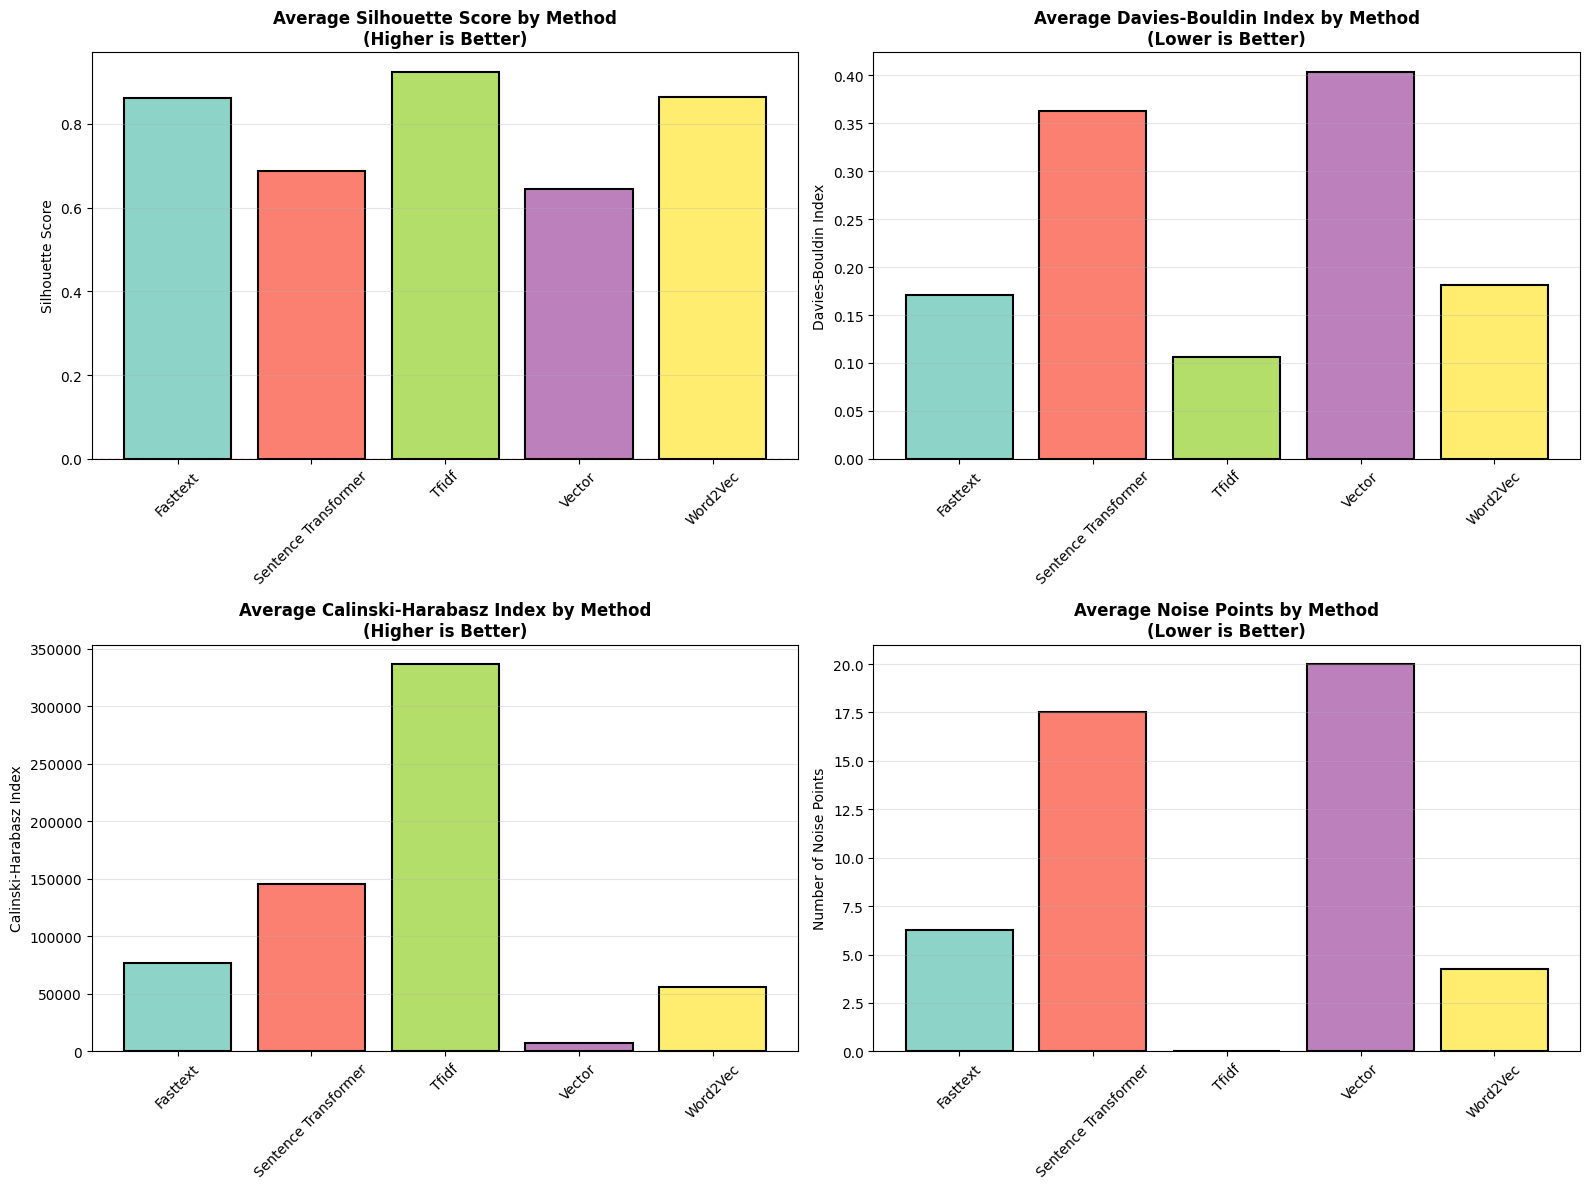

✓ Saved method comparison charts


In [60]:
# Create comparison bar charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

methods = avg_metrics.index
colors = plt.cm.Set3(np.linspace(0, 1, len(methods)))

# Silhouette Score (higher is better)
axes[0, 0].bar(methods, avg_metrics['Silhouette'], color=colors, edgecolor='black', linewidth=1.5)
axes[0, 0].set_title('Average Silhouette Score by Method\n(Higher is Better)', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Davies-Bouldin Index (lower is better)
axes[0, 1].bar(methods, avg_metrics['Davies-Bouldin'], color=colors, edgecolor='black', linewidth=1.5)
axes[0, 1].set_title('Average Davies-Bouldin Index by Method\n(Lower is Better)', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Davies-Bouldin Index')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Calinski-Harabasz Index (higher is better)
axes[1, 0].bar(methods, avg_metrics['Calinski-Harabasz'], color=colors, edgecolor='black', linewidth=1.5)
axes[1, 0].set_title('Average Calinski-Harabasz Index by Method\n(Higher is Better)', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Calinski-Harabasz Index')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Noise Points (lower is better)
axes[1, 1].bar(methods, avg_metrics['Noise Points'], color=colors, edgecolor='black', linewidth=1.5)
axes[1, 1].set_title('Average Noise Points by Method\n(Lower is Better)', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Number of Noise Points')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "method_comparison_charts.png"), dpi=150)
plt.show()

print("✓ Saved method comparison charts")

## Summary

This notebook performs comprehensive workload clustering analysis comparing multiple approaches:

### Feature Extraction Methods:
1. **Vector-based**: Structural SQL features (joins, aggregates, predicates, complexity)

### Embedding Methods Compared:
2. **FastText**: Subword-aware embeddings, handles rare/OOV tokens well
3. **Word2Vec**: Classic context-based word embeddings
4. **TF-IDF**: Statistical importance weighting, interpretable features
5. **Sentence Transformers**: Pre-trained BERT-based contextual embeddings

### Pipeline:
- **Dimensionality Reduction**: UMAP (non-linear) and PCA (linear)
- **Clustering**: HDBSCAN with hyperparameter grid search
- **Evaluation**: Silhouette, Davies-Bouldin, Calinski-Harabasz, Inertia metrics
- **Output**: Visualizations, metrics CSV, representative workload selection

### Key Findings:
- Compare methods to identify which embedding type best captures SQL workload similarity
- Vector-based features provide interpretable structural information
- Different embedding methods may excel for different benchmark types
- Sentence Transformers leverage pre-trained knowledge but are computationally expensive
- FastText/Word2Vec are lightweight and fast for large workload collections

## 10. Save and Display Results

In [61]:
# Save metrics to CSV
df_metrics = pd.DataFrame(summary_results)
df_metrics.to_csv(os.path.join(output_dir, "clustering_metrics_final.csv"), index=False)

print("\n" + "="*60)
print("CLUSTERING ANALYSIS COMPLETE")
print("="*60)
print(f"\nResults saved to: {output_dir}")
print(f"Metrics saved to: clustering_metrics_final.csv\n")

# Display results
print("\nClustering Metrics Summary:")
print(df_metrics.to_string(index=False))


CLUSTERING ANALYSIS COMPLETE

Results saved to: /Users/nisith/Desktop/FYP/E2ETune-AI4DB/Workload Clustering OLAP/clustering_output
Metrics saved to: clustering_metrics_final.csv


Clustering Metrics Summary:
Benchmark               Method  Silhouette  Davies-Bouldin  Calinski-Harabasz     Inertia  Noise Points
    tpcds               Vector    0.615152        0.420768        7210.681844    2.071694            18
    tpcds             Fasttext    0.872777        0.181399        5422.424447  251.832062             0
    tpcds             Word2Vec    0.874827        0.183496        5746.349847  280.850922             0
    tpcds                Tfidf    0.869490        0.181724        5213.355339  250.388916             0
    tpcds Sentence Transformer    0.602868        0.420474        1803.740341    2.374025            23
      ssb               Vector    0.656040        0.429308       10546.631789   17.478085            33
      ssb             Fasttext    0.955665        0.063700     

## Summary

This notebook performs comprehensive workload clustering analysis comparing:
- **Vector-based features**: Structural SQL features aggregated across workloads
- **Word embeddings**: FastText embeddings of SQL tokens

Key outputs:
1. Clustering visualizations (UMAP and PCA) for each benchmark
2. Evaluation metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz, Inertia)
3. Representative workload selection based on cluster centroids
4. Comprehensive metrics CSV for further analysis